## Quadratic density modification
$$R(z) = re^{-\alpha z^2}$$

In [62]:
from scipy.integrate import solve_ivp
import numpy as np

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    directions_num = 2
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    mass_modification = kwargs.get("mass_modification", 5)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, mass_modification), t_eval=t_eval, method="BDF")
        sol.append(solution.y[0] + 1j * solution.y[1])
    return sol


def drift_func(z, sigma, lamb, pullback, mass_modification):
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        return drift-pullback*(drift-2*mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        return drift-pullback*(drift-2*mass_modification*z) / (np.exp(-action_mod)+pullback)

drift_func = np.vectorize(drift_func)


def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_51626/3396022976.py:58: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_51626/3396022976.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


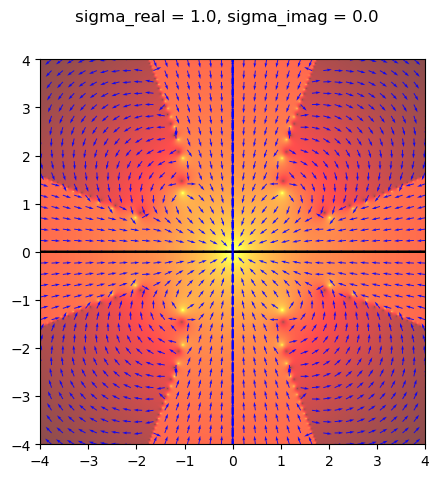

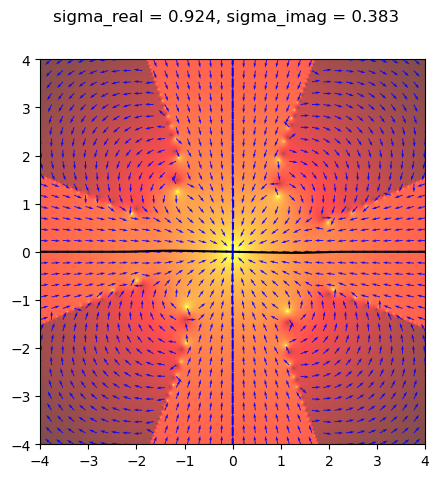

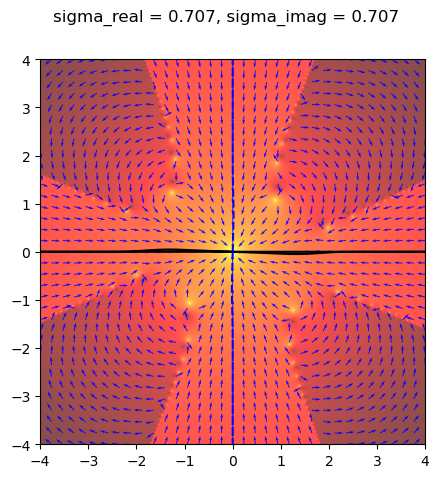

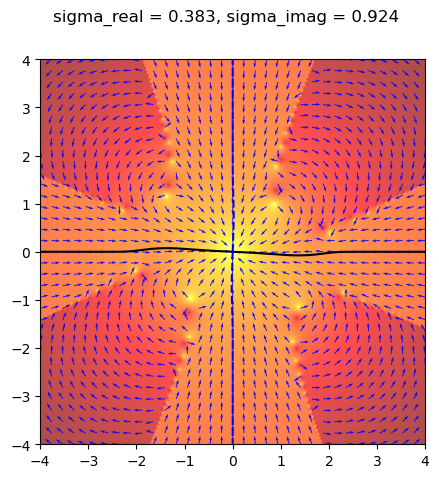

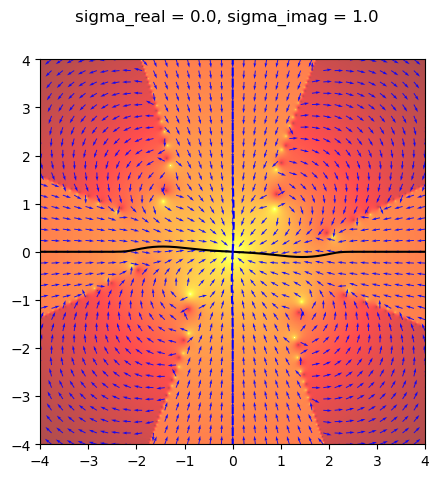

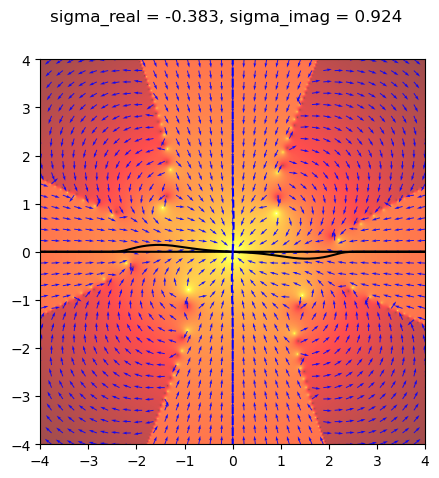

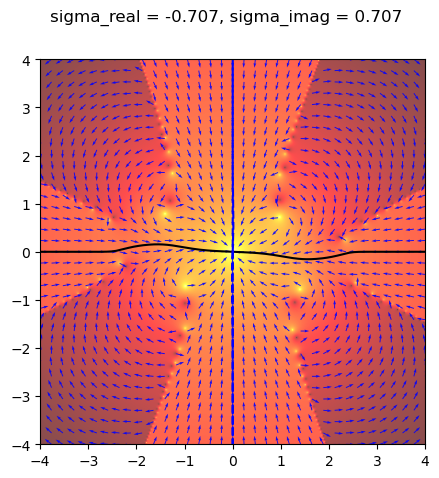

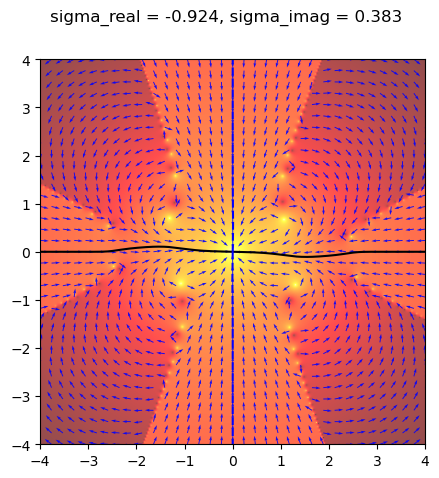

In [68]:

lamb = 1
sigma_abs = 1

start_angle = 0
stop_angle = np.pi

num = 8
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

mass_modification = 1
pullback = 5

import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'blue', ls = '--')  # Set transparency for better visibility

    x_range = (-4, 4)
    y_range = (-4, 4)

    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)
    fig.show()

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_51626/1895440671.py:58: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_51626/1895440671.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


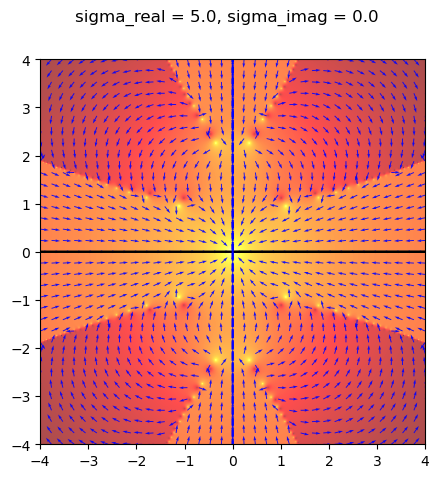

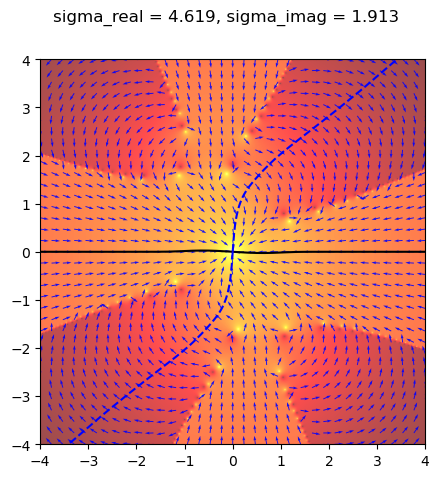

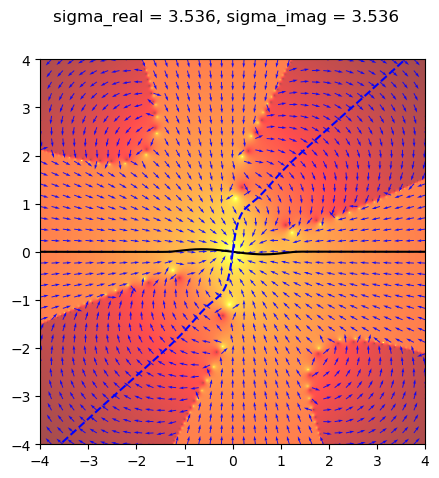

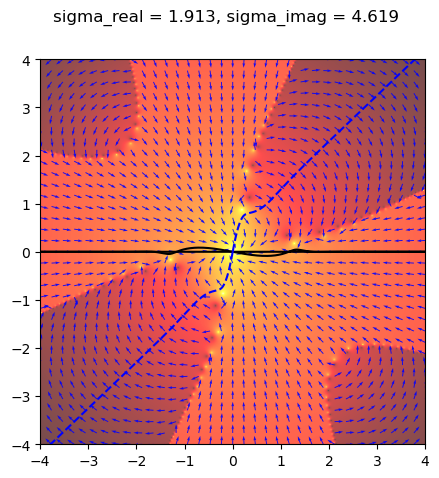

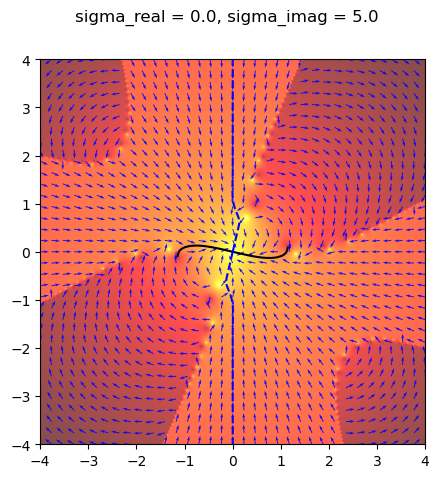

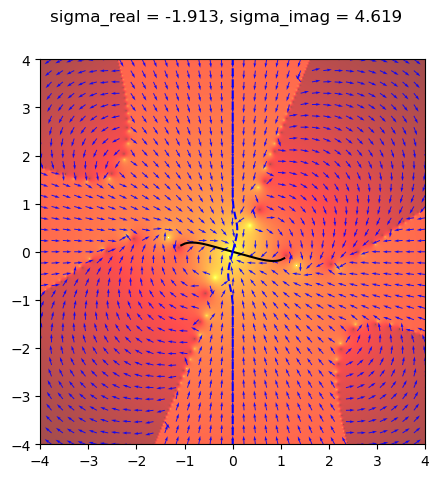

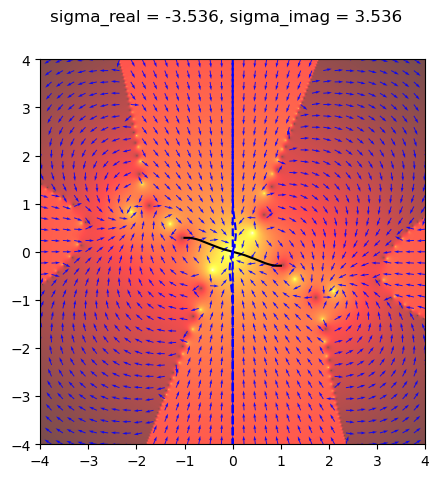

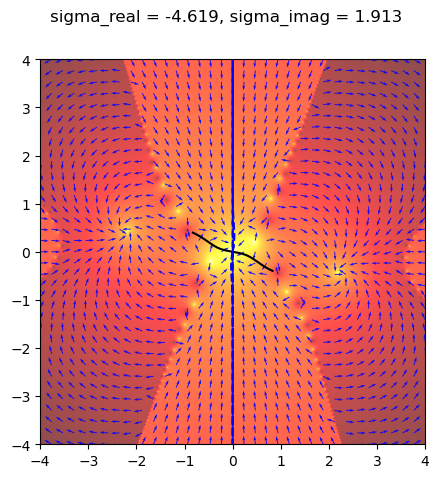

In [70]:

lamb = 1
sigma_abs = 5

start_angle = 0
stop_angle = np.pi

num = 8
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

mass_modification = 1
pullback = 5

import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'blue', ls = '--')  # Set transparency for better visibility

    x_range = (-4, 4)
    y_range = (-4, 4)

    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)
    fig.show()

TypeError: drift_func() got an unexpected keyword argument 'phi_singular'

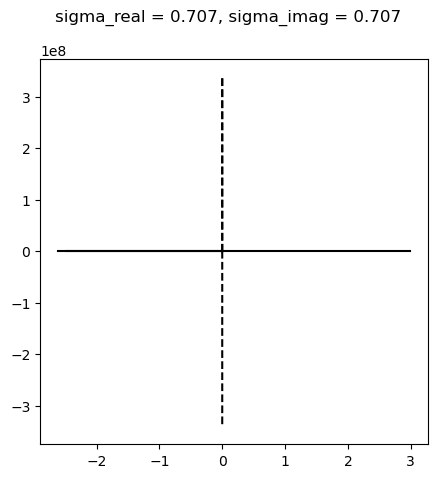

In [53]:


lamb = 1
sigma_abs = 1

start_angle = np.pi/4
stop_angle = np.pi

num = 4
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

phi_singular = 2
pullback = 2



import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 80000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility
    # y_range = ax.get_ylim()

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 80000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black', ls = '--')  # Set transparency for better visibility

    x_range = (-3, 3)
    y_range = (-3, 3)
    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    fig.show()
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)

We want to artificially introduce zeros in the density by a additive modification of the action. 
$$
S \to \tilde{S} = \frac{\sigma}{2}z^2+\frac{\lambda}{4}z^4+\psi(z)\qquad \rho \to \tilde{\rho} = \rho + R(z)
$$
forcing $\tilde{\rho} = \tilde{S}$ gives
$$
\psi(z) = -\ln(1+R(z)e^{S})
$$

As an example, we want to generate a zero in $\tilde{\rho}$ at a finite $z = z_{0}$. 
This is achieved by setting $R(z) = -\rho(z_{0})$ resulting in 
$$
\psi(z) = -\ln\left( 1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right) \right)
$$
The drift is calculated
$$
\partial_{z}\tilde{S} = \partial_{z}S+\partial_{z}\psi= \partial_{z}S+\frac{\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}{1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}\partial_{z}S= \partial_{z}S\, \left[ 1+\frac{\exp{\{S(z)-S(z_{0})\}}}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$
Further simplifying
$$
\partial_{z}\tilde{S} = \partial_{z}S \, \left[ \frac{1}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$

In [37]:
from sympy import symbols, diff, Function, re, im, sqrt, exp, I
import sympy as sp
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = -exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))

drift_mod = sp.diff(action_mod, z).simplify()
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 + sigma)*exp(z_0**2*(lambda*z_0**2/2 + sigma))/(exp(z_0**2*(lambda*z_0**2/2 + sigma)) - exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2))

In [38]:
def action_mod_func(z, z0, r, sigma, lamb):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    out = action

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if overflow:
        out -= 1j*np.pi + delta_s
    else:
        out -= np.log(1-np.exp(delta_s))
    return out

action_mod_func = np.vectorize(action_mod_func)

In [39]:
def drift_mod_func(z, z0, r, sigma, lamb):
    drift = lamb * z**3 + sigma * z
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if delta_s == 0: return np.inf
    if overflow:
        out = -drift*np.exp(-delta_s)
    else:
        out = drift / (1-np.exp(delta_s))
    return out

drift_mod_func = np.vectorize(drift_mod_func)


Let's look at the modification 
$$
R(z) = r(z^2-z_0^2)-\rho(-S_0)
$$

In [41]:
from sympy import symbols, diff, Function, re, im, sqrt, exp
import sympy as sp
sigma_r, lamb_r = symbols('sigma_r, lambda_r', real=True)
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi', real=True)
sigma, lamb = sigma_r*exp(sp.I*sigma_phi), lamb_r*exp(sp.I*lamb_phi)
z_phi, z_r = symbols('z_phi, z_r', real=True)
z = z_r*exp(sp.I*z_phi)
z = symbols('z')
# sigma, lamb = symbols('sigma lambda')
action = sigma/2*z**2 + lamb/4*z**4

In [42]:
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = r*(z**2-z_0**2)-exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))
action_mod_func = sp.lambdify((z, z_0, sigma, lamb, r), action_mod, 'numpy')

drift_mod = sp.diff(action_mod, z).simplify()
drift_mod_func  = sp.lambdify((symbols('t z z_0 sigma lambda r')), drift_mod,  'numpy')
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 - 2*r*exp(lambda*z**4/4 + sigma*z**2/2) + sigma)*exp(lambda*z_0**4/4 + sigma*z_0**2/2)/(r*z**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - r*z_0**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - exp(lambda*z**4/4 + sigma*z**2/2) + exp(lambda*z_0**4/4 + sigma*z_0**2/2))